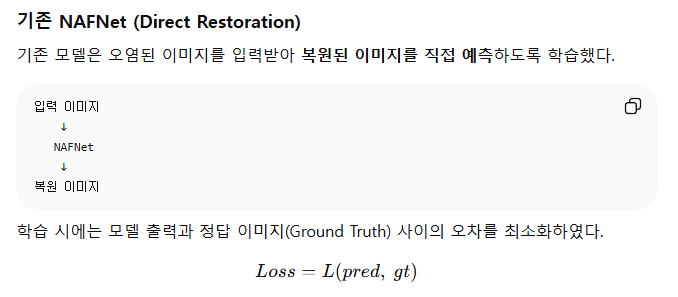

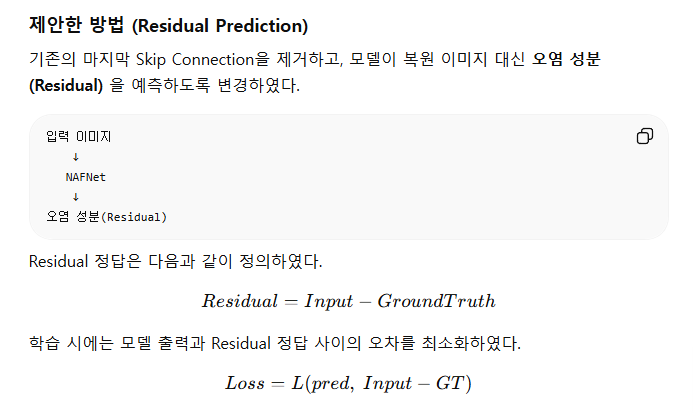

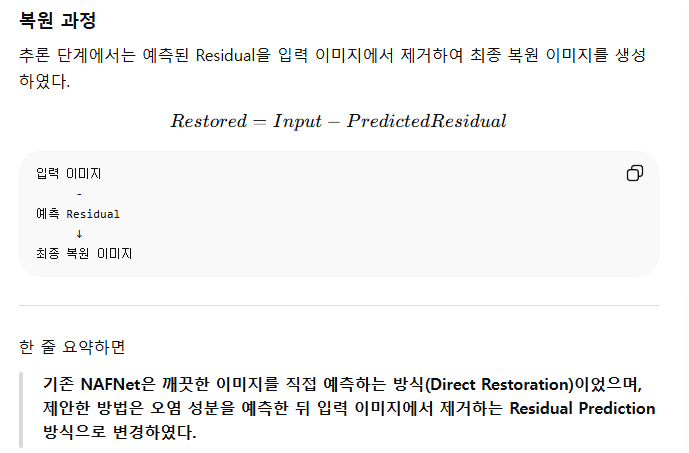

### BaseModel 변경사항


In [ ]:
# 기존에 있는 코드 
x = self.ending(x)
x = x + inp

return x[:, :, :H, :W]

# 기존 아키텍처 - NAFNet_arch.py 를 수정함 , 마지막 잔차 넘기는 부분만 수정함 
# 여기 부분만 수정 - 오염부분만 추출해서 원본에서 빼주는 방식으로 변경 ( 실험해볼거임 )
x = self.ending(x)

return x[:, :, :H, :W]

### Validation 변경사항

In [ ]:
    def optimize_parameters(self, current_iter, tb_logger):
        self.optimizer_g.zero_grad()

        if self.opt['train'].get('mixup', False):
            self.mixup_aug()

        preds = self.net_g(self.lq)
        if not isinstance(preds, list):
            preds = [preds]

        self.output = preds[-1]

        l_total = 0
        loss_dict = OrderedDict()
        # pixel loss
        if self.cri_pix:
            l_pix = 0.
            for pred in preds:
                l_pix += self.cri_pix(pred, self.gt)



# 실험을 위해 기존 아키텍처 image_restoration_model.py를 수정함 
    def optimize_parameters(self, current_iter, tb_logger):
        self.optimizer_g.zero_grad()

        if self.opt['train'].get('mixup', False):
            self.mixup_aug()

        preds = self.net_g(self.lq)
        if not isinstance(preds, list):
            preds = [preds]

        # 실험을 위한 부분 - 오염부분만 추출해서 원본에서 빼주는 방식으로 변경 ( 실험해볼거임 )
        target_residual = self.lq - self.gt
        self.output = preds[-1]

        l_total = 0
        loss_dict = OrderedDict()
        # pixel loss
        if self.cri_pix:
            l_pix = 0.
            for pred in preds: # 여기 부분만 수정 - 오염부분만 추출해서 원본에서 빼주는 방식으로 변경 ( 실험해볼거임 )
                l_pix += self.cri_pix(
                    pred,
                    target_residual
                )



### Validation 변경사항 2 

In [ ]:
pred = self.net_g(self.lq[i:j])

if isinstance(pred, list):
    pred = pred[-1]

outs.append(pred.detach().cpu())

# 실험을 위해 기존 아키텍처 image_restoration_model.py를 수정함
pred = self.net_g(self.lq[i:j])

if isinstance(pred, list):
    pred = pred[-1]

restored = self.lq[i:j] - pred

outs.append(restored.detach().cpu())